# 🏡 House Price Prediction — Streamlined & Interpretable ML
*A clean, end-to-end regression workflow predicting house sale prices using regularized linear models (Ridge & Lasso).*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Clean plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
print("Setup complete. Libraries loaded successfully.")

Setup complete. Libraries loaded successfully.


## 1. Data Ingestion & Target Variable
We load the Ames housing dataset and inspect the target variable `SalePrice`. Real estate prices typically exhibit strong right-skewness (a small number of high-end luxury homes pull the mean to the right). Applying a log-transformation $\log(1 + x)$ normalizes the residuals and stabilizes variance for linear models.

In [ ]:
df = pd.read_csv('Dataset/train.csv')
print(f"Dataset shape: {df.shape[0]} homes, {df.shape[1]} attributes")
df[['SalePrice', 'GrLivArea', 'OverallQual', 'YearBuilt', 'Neighborhood']].head()


Dataset shape: 1460 homes, 81 attributes


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

## 2. Target Distribution & Outlier Treatment
The official Ames documentation recommends removing the 2 extreme houses with `GrLivArea > 4000 sq ft` with low sale prices, as they act as severe high-leverage outliers for linear models.

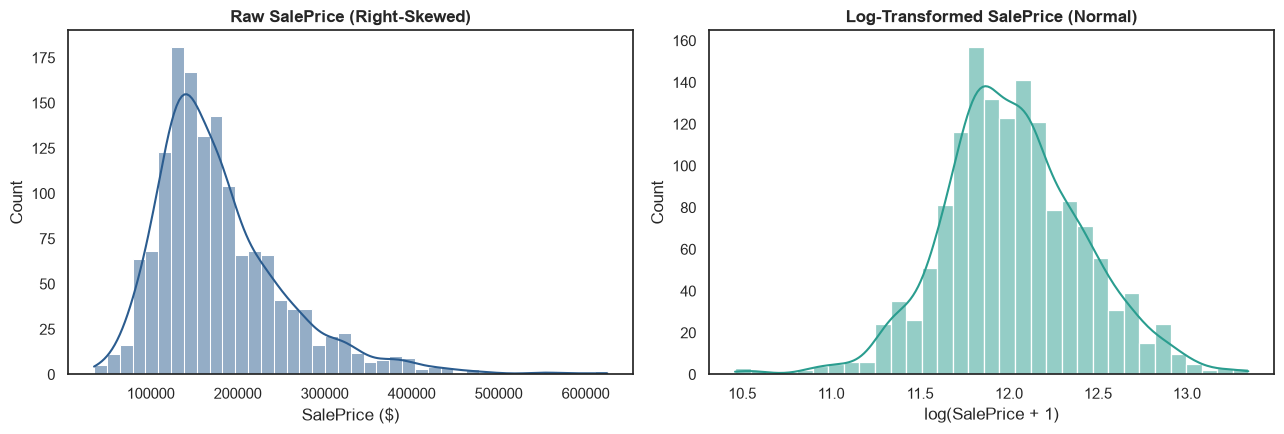

In [21]:
# Remove documented extreme square footage outliers
df = df[df['GrLivArea'] < 4000].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Raw SalePrice
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Raw SalePrice (Right-Skewed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')

# Log-Transformed SalePrice
y = np.log1p(df['SalePrice'])
sns.histplot(y, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Log-Transformed SalePrice (Normal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(SalePrice + 1)')

plt.tight_layout()
plt.show()

## 3. Human Feature Engineering
Real estate valuation depends strongly on intuitive aggregate metrics. Instead of arbitrary column drops, we build features appraisers actually care about:
- **`TotalSF`**: Total Basement + 1st Floor + 2nd Floor (the single highest value driver).
- **`TotalBath`**: Full baths + 0.5 * Half baths (above ground + basement).
- **`TotalPorchSF`**: Combined outdoor entertaining space.
- **`HouseAge` & `YearsSinceRemodel`**: Property age and modernization timeline.
- **Quality Ratings**: Ordinal encoding for quality variables (`Ex: 5, Gd: 4, TA: 3, Fa: 2, Po: 1, None: 0`).

In [ ]:


# 1. Total Square Footage
X['TotalSF'] = X['TotalBsmtSF'].fillna(0) + X['1stFlrSF'] + X['2ndFlrSF']

# 2. Total Bathrooms
X['TotalBath'] = (
    X['FullBath'] + 0.5 * X['HalfBath']
    + X['BsmtFullBath'].fillna(0) + 0.5 * X['BsmtHalfBath'].fillna(0)
)

# 3. Outdoor Living Space
X['TotalPorchSF'] = (
    X['WoodDeckSF'] + X['OpenPorchSF'] + X['EnclosedPorch']
    + X['3SsnPorch'] + X['ScreenPorch']
)

# 4. Property Age Dynamics
X['HouseAge'] = X['YrSold'] - X['YearBuilt']
X['YearsSinceRemodel'] = X['YrSold'] - X['YearRemodAdd']
X['IsRemodeled'] = (X['YearRemodAdd'] != X['YearBuilt']).astype(int)

# 5. Ordinal Quality Mappings
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, np.nan: 0}
qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond'
]
for col in qual_cols:
    if col in X.columns:
        X[col] = X[col].map(qual_map).fillna(0)

# 6. Clean missing values
# Categoricals: missing indicates absence of feature (no garage, no pool, etc.)
cat_cols = X.select_dtypes(include=['object', 'string']).columns
X[cat_cols] = X[cat_cols].fillna('None')

# Numerics: impute with median
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# 7. One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)
print(f"Engineered Feature Matrix: {X.shape[0]} houses, {X.shape[1]} features.")

Engineered Feature Matrix: 1456 houses, 237 features.


## 4. Train-Test Split & Feature Scaling
Regularization penalizes large coefficients. If variables are on different scales (e.g. square footage vs number of bathrooms), the penalty unfairly punishes features with larger numerical units. `StandardScaler` places all features on standard normal zero-mean, unit-variance scales.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

NameError: name 'StandardScaler' is not defined

## 5. Model Training: Ridge ($L_2$) and Lasso ($L_1$) with Cross-Validation
- **Ridge Regression**: Adds an $L_2$ penalty ($\alpha \sum \beta_j^2$). Effectively shrinks collinear predictors together, handling multicollinearity gracefully.
- **Lasso Regression**: Adds an $L_1$ penalty ($\alpha \sum |\beta_j|$). Performs sparse feature selection by driving irrelevant feature weights to exactly zero.
- **HistGradientBoosting**: State-of-the-art tree-based ensemble to benchmark non-linear relationships.

In [ ]:
# Ridge with 5-fold cross-validation
ridge_alphas = np.logspace(-2, 3, 50)
ridge = RidgeCV(alphas=ridge_alphas, cv=5).fit(X_train_scaled, y_train)

# Lasso with 5-fold cross-validation
lasso_alphas = np.logspace(-4, -1, 50)
lasso = LassoCV(alphas=lasso_alphas, cv=5, max_iter=10000, random_state=42).fit(X_train_scaled, y_train)

# Gradient Boosting Benchmark
hgb = HistGradientBoostingRegressor(random_state=42).fit(X_train, y_train)

print(f"Optimal Ridge alpha: {ridge.alpha_:.2f}")
print(f"Optimal Lasso alpha: {lasso.alpha_:.5f}")

Optimal Ridge alpha: 308.88
Optimal Lasso alpha: 0.00391


## 6. Model Evaluation: Statistical & Business Metrics
We evaluate both $R^2$ (variance explained) and practical real-world dollar accuracy:
- **MAE ($)**: Mean Absolute Error in dollars (what is the expected average error on a house appraisal?).
- **RMSE ($)**: Root Mean Squared Error (penalizes large outlier misses).

In [ ]:
models = {
    f"Ridge (alpha={ridge.alpha_:.1f})": (ridge, X_train_scaled, X_test_scaled),
    f"Lasso (alpha={lasso.alpha_:.4f})": (lasso, X_train_scaled, X_test_scaled),
    "HistGradientBoosting": (hgb, X_train, X_test)
}

rows = []
y_test_dollars = np.expm1(y_test)

for name, (model, X_tr, X_te) in models.items():
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    
    r2_tr = r2_score(y_train, pred_tr)
    r2_te = r2_score(y_test, pred_te)
    
    pred_dollars = np.expm1(pred_te)
    mae = mean_absolute_error(y_test_dollars, pred_dollars)
    rmse = np.sqrt(mean_squared_error(y_test_dollars, pred_dollars))
    
    rows.append({
        "Model": name,
        "Train R²": round(r2_tr, 4),
        "Test R²": round(r2_te, 4),
        "Test MAE ($)": f"${mae:,.2f}",
        "Test RMSE ($)": f"${rmse:,.2f}"
    })

comparison_df = pd.DataFrame(rows)
comparison_df

,Model,Train R²,Test R²,Test MAE ($),Test RMSE ($)
0,Ridge (alpha=308.9),0.9396,0.8969,"$14,808.54","$21,072.88"
1,Lasso (alpha=0.0039),0.9351,0.9070,"$13,408.37","$19,006.68"
2,HistGradientBoosting,0.9913,0.8793,"$15,403.76","$22,630.26"


## 7. Model Diagnostics: Actual vs Predicted & Residuals
We verify that predictions align along the 45-degree diagonal and errors are symmetrically distributed around zero.

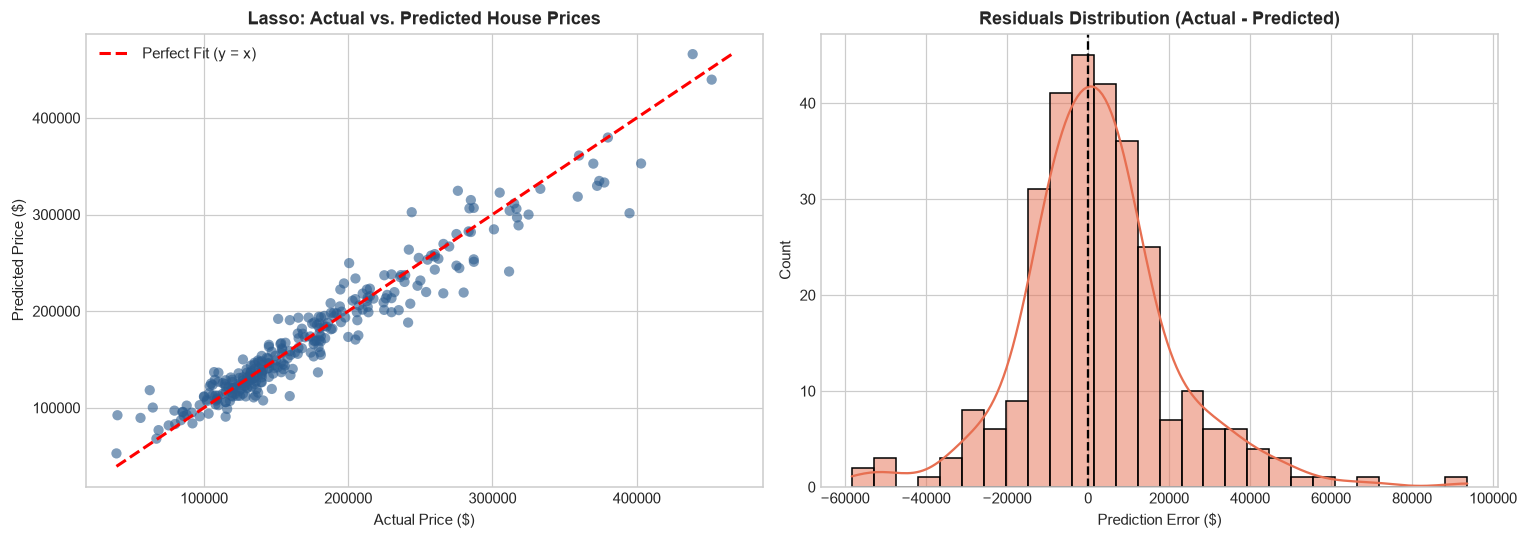

In [ ]:
best_preds_log = lasso.predict(X_test_scaled)
best_preds_dollars = np.expm1(best_preds_log)
residuals = y_test_dollars - best_preds_dollars

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_dollars, best_preds_dollars, alpha=0.6, color='#2b5c8f', edgecolors='none', s=45)
min_val = min(y_test_dollars.min(), best_preds_dollars.min())
max_val = max(y_test_dollars.max(), best_preds_dollars.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit (y = x)')
axes[0].set_title('Lasso: Actual vs. Predicted House Prices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#e76f51')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Residuals Distribution (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

## 8. Business Interpretability: Top Price Drivers
Which features matter most when appraising a home? Lasso regression reduced the 237 input features down to the most significant predictors by setting irrelevant weights to zero.

Features selected by Lasso: 76 out of 237 total features.


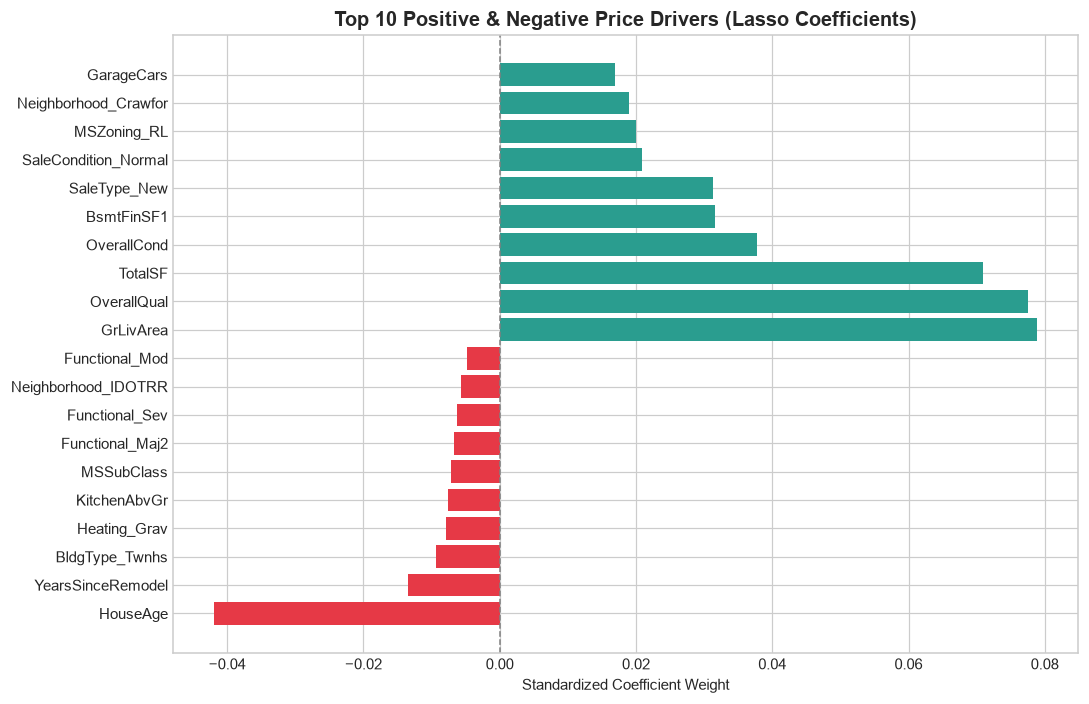

In [ ]:
coefs = pd.Series(lasso.coef_, index=X_train.columns)
non_zero = (coefs != 0).sum()
print(f"Features selected by Lasso: {non_zero} out of {len(coefs)} total features.")

top_pos = coefs.sort_values(ascending=False).head(10)
top_neg = coefs.sort_values().head(10)
top_coefs = pd.concat([top_neg, top_pos])

colors = ['#e63946' if x < 0 else '#2a9d8f' for x in top_coefs.values]

plt.figure(figsize=(10, 6.5))
plt.barh(top_coefs.index, top_coefs.values, color=colors)
plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.title('Top 10 Positive & Negative Price Drivers (Lasso Coefficients)', fontsize=13, fontweight='bold')
plt.xlabel('Standardized Coefficient Weight')
plt.tight_layout()
plt.show()

## 9. Sample Predictions & Error Analysis
Let's inspect actual predictions on individual test properties to see how close our estimates are in real dollars.

In [ ]:
demo_df = pd.DataFrame({
    'Actual Price': y_test_dollars.iloc[:5].values,
    'Predicted Price': best_preds_dollars[:5].round(0),
})
demo_df['Difference ($)'] = demo_df['Predicted Price'] - demo_df['Actual Price']
demo_df['Absolute Error (%)'] = (demo_df['Difference ($)'].abs() / demo_df['Actual Price'] * 100).round(2)
demo_df

,Actual Price,Predicted Price,Difference ($),Absolute Error (%)
0,184000.0,171980.0,-12020.0,6.53
1,181000.0,154733.0,-26267.0,14.51
2,145000.0,131895.0,-13105.0,9.04
3,115000.0,128474.0,13474.0,11.72
4,84000.0,87087.0,3087.0,3.67
